In [1]:
import os
from pathlib import Path


model_weights_path = "../trained_models/penalized-rc1-customers-10"
dataset_path = Path("../dataset/solomon_rc100")
model_weights = [f for f in os.listdir(model_weights_path) if f.endswith(".ckpt")]

def parse_file_name(file_name):
    parts = file_name.split("-")[3:]
    print(parts)
    return {
        "family": parts[0],
        "num_customers": int(parts[2]),
        "penalty": float(parts[4]),
        "learning_rate": float(parts[6]),
        "seed": int(parts[8].split(".")[0])
    }

In [2]:
from dvrptw_bench.data.instance_filters import find_rc_instances
from dvrptw_bench.data.solomon_parser import parse_solomon


instances = [parse_solomon(instance, max_customers=10) for instance in find_rc_instances(dataset_path)]

In [3]:
from dvrptw_bench.heuristics.ortools_solver import ORToolsVRPTWSolver


orSolver= ORToolsVRPTWSolver()
or_solutions = {instance.instance_id: orSolver.solve(instance, time_limit_s=10) for instance in instances}

In [4]:

from dvrptw_bench.data.der_solomon_generator import DERTimeWindowGenerator, Depot, SolomonSeriesTemplate, Customer
from dvrptw_bench.data.rl4co_der_generator import DERSolomonCVRPTWGenerator, FamilySpec
from dvrptw_bench.rl.penalized_cvrptw_env import PenalizedCVRPTWEnv
from dvrptw_bench.rl.rl4co_policy import RL4COPolicy
from dvrptw_bench.rl.rl_model import build_attention_model

rl_solutions = {}
for file_name in model_weights:
    params = parse_file_name(file_name)
    model = build_attention_model(
        normalize_coords=False,
    )
    model.load(os.path.join(model_weights_path, file_name))
    policy = RL4COPolicy(model=model)

    for instance in instances:
        solution = policy.infer_instance(instance, decode_type="sampling", num_samples=1024, select_best=True)
        rl_solutions[instance.instance_id + "_" + file_name] = solution 


/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of t

['RC1', 'customers', '10', 'penalty', '0', 'lr', '0.0005', 'seed', '7960100.ckpt']


/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['baseline.baseline.policy.encoder.init_embedding.init_embed.weight', 'baseline.baseline.policy.encoder.init_embedding.init_embed.bias', 'baseline.baseline.policy.encoder.init_embedding.init_embed_depot.weight', 'baseline.baseline.policy.encoder.init_embedding.init_embed_depot.bias', 'baseline.baseline.policy.encoder.net.layers.0.0.module.Wqkv.weight', 'baseline.baseline.policy.encoder.net.layers.0.0.module.Wqkv.bias', 'baseline.baseline.policy.encoder.net.layers.0.0.module.out_proj.weight', 'baseline.baseline.policy.encoder.net.layers.0.0.module.out_proj.bias', 'baseline.baseline.policy.encoder.net.layers.0.1.normalizer.weight', 'baseline.baseline.policy.encoder.net.layers.0.1.normalizer.bias', 'baseline.baseline.policy.encoder.net.layers.0.1.normalizer.running_mean', 'baseline.baseli

['RC1', 'customers', '10', 'penalty', '100', 'lr', '0.0001', 'seed', '6238116.ckpt']


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

['RC1', 'customers', '10', 'penalty', '10', 'lr', '0.0005', 'seed', '7960100.ckpt']


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


['RC1', 'customers', '10', 'penalty', '500', 'lr', '0.0001', 'seed', '7454245.ckpt']


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


['RC1', 'customers', '10', 'penalty', '10', 'lr', '0.0001', 'seed', '7960100.ckpt']


['RC1', 'customers', '10', 'penalty', '0', 'lr', '0.0005', 'seed', '7960100.ckpt']
['RC1', 'customers', '10', 'penalty', '0', 'lr', '0.0005', 'seed', '7960100.ckpt']
['RC1', 'customers', '10', 'penalty', '0', 'lr', '0.0005', 'seed', '7960100.ckpt']
['RC1', 'customers', '10', 'penalty', '0', 'lr', '0.0005', 'seed', '7960100.ckpt']
['RC1', 'customers', '10', 'penalty', '0', 'lr', '0.0005', 'seed', '7960100.ckpt']
['RC1', 'customers', '10', 'penalty', '0', 'lr', '0.0005', 'seed', '7960100.ckpt']
['RC1', 'customers', '10', 'penalty', '0', 'lr', '0.0005', 'seed', '7960100.ckpt']
['RC1', 'customers', '10', 'penalty', '0', 'lr', '0.0005', 'seed', '7960100.ckpt']
['RC1', 'customers', '10', 'penalty', '100', 'lr', '0.0001', 'seed', '6238116.ckpt']
['RC1', 'customers', '10', 'penalty', '100', 'lr', '0.0001', 'seed', '6238116.ckpt']
['RC1', 'customers', '10', 'penalty', '100', 'lr', '0.0001', 'seed', '6238116.ckpt']
['RC1', 'customers', '10', 'penalty', '100', 'lr', '0.0001', 'seed', '6238116.ckp

,model_id,instance_id,family,penalty,learning_rate,seed,rl_distance,gap_vs_or_%
0,M01,RC201.txt,RC1,0.0,0.0001,6238116,256.809,40.23
1,M02,RC201.txt,RC1,0.0,0.0001,7454245,191.233,4.42
2,M03,RC201.txt,RC1,0.0,0.0001,7960100,236.632,29.21
3,M04,RC201.txt,RC1,0.0,0.0005,6238116,247.510,35.15
4,M05,RC201.txt,RC1,0.0,0.0005,7454245,565.294,208.67
5,M06,RC201.txt,RC1,0.0,0.0005,7960100,247.510,35.15
6,M07,RC201.txt,RC1,10.0,0.0001,6238116,227.910,24.45
7,M08,RC201.txt,RC1,10.0,0.0001,7454245,328.207,79.22
8,M09,RC201.txt,RC1,10.0,0.0001,7960100,654.043,257.14
9,M10,RC201.txt,RC1,10.0,0.0005,6238116,247.510,35.15


Aggregated by hyperparameters (across seeds):


,family,penalty,learning_rate,n_seeds,best_distance,mean_distance,std_distance,best_gap_vs_or_%,mean_gap_vs_or_%
0,RC1,0.0,0.0001,3,191.233,228.224,33.586,4.42,24.62
1,RC1,0.0,0.0005,3,247.510,353.438,183.473,35.15,92.99
2,RC1,10.0,0.0001,3,227.910,403.386,222.792,24.45,120.27
3,RC1,10.0,0.0005,3,247.510,403.327,269.884,35.15,120.23
4,RC1,50.0,0.0001,3,199.809,308.889,165.484,9.10,68.67
5,RC1,50.0,0.0005,3,247.510,247.510,0.000,35.15,35.15
6,RC1,100.0,0.0001,3,207.379,235.725,26.272,13.24,28.72
7,RC1,500.0,0.0001,3,292.855,422.247,201.822,59.91,130.56
8,RC1,1000.0,0.0001,3,292.573,413.341,209.108,59.76,125.70


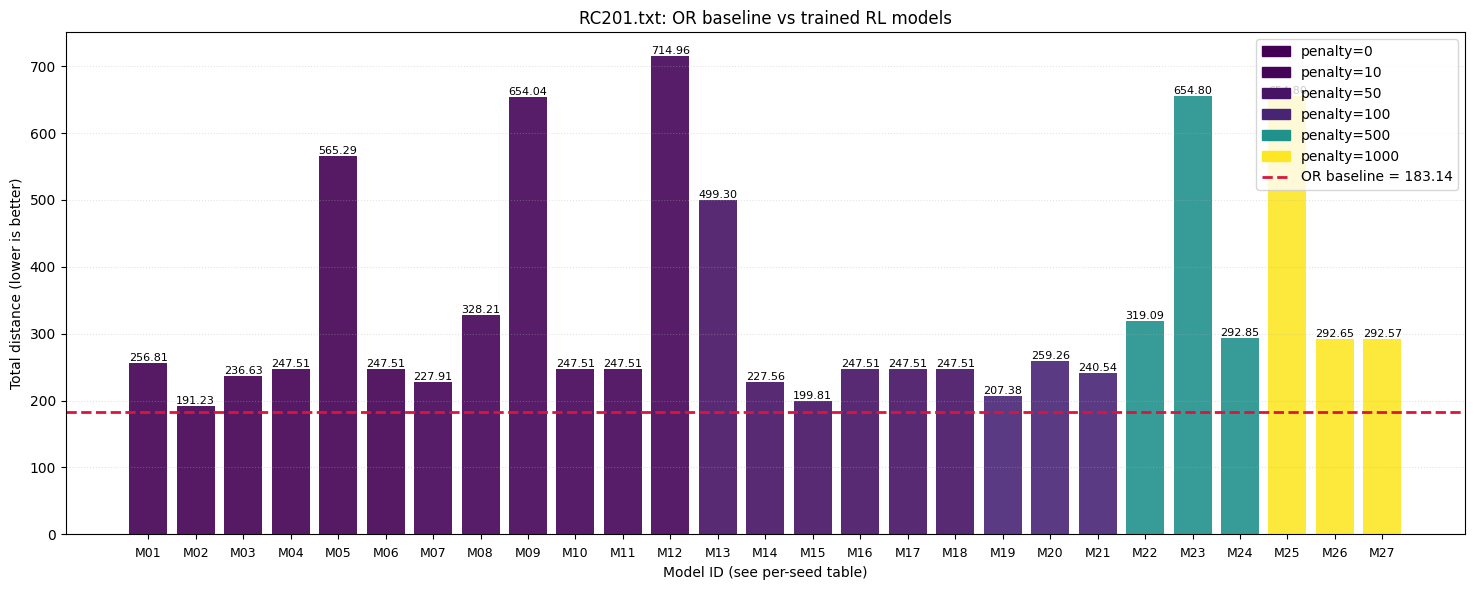


=== RC202.txt | OR baseline: 166.049 ===
Per-seed comparison (model_id matches x-axis):


,model_id,instance_id,family,penalty,learning_rate,seed,rl_distance,gap_vs_or_%
0,M01,RC202.txt,RC1,0.0,0.0001,6238116,176.311,6.18
1,M02,RC202.txt,RC1,0.0,0.0001,7454245,254.063,53.01
2,M03,RC202.txt,RC1,0.0,0.0001,7960100,185.628,11.79
3,M04,RC202.txt,RC1,0.0,0.0005,6238116,183.918,10.76
4,M05,RC202.txt,RC1,0.0,0.0005,7454245,626.213,277.13
5,M06,RC202.txt,RC1,0.0,0.0005,7960100,183.918,10.76
6,M07,RC202.txt,RC1,10.0,0.0001,6238116,215.576,29.83
7,M08,RC202.txt,RC1,10.0,0.0001,7454245,288.615,73.81
8,M09,RC202.txt,RC1,10.0,0.0001,7960100,714.962,330.57
9,M10,RC202.txt,RC1,10.0,0.0005,6238116,183.918,10.76


Aggregated by hyperparameters (across seeds):


,family,penalty,learning_rate,n_seeds,best_distance,mean_distance,std_distance,best_gap_vs_or_%,mean_gap_vs_or_%
0,RC1,0.0,0.0001,3,176.311,205.334,42.457,6.18,23.66
1,RC1,0.0,0.0005,3,183.918,331.350,255.359,10.76,99.55
2,RC1,10.0,0.0001,3,215.576,406.384,269.720,29.83,144.74
3,RC1,10.0,0.0005,3,183.918,360.933,306.598,10.76,117.37
4,RC1,50.0,0.0001,3,181.488,222.387,37.624,9.30,33.93
5,RC1,50.0,0.0005,3,183.918,183.918,0.000,10.76,10.76
6,RC1,100.0,0.0001,3,220.022,231.172,18.461,32.50,39.22
7,RC1,500.0,0.0001,3,182.973,351.020,263.575,10.19,111.40
8,RC1,1000.0,0.0001,3,221.430,323.757,142.368,33.35,94.98


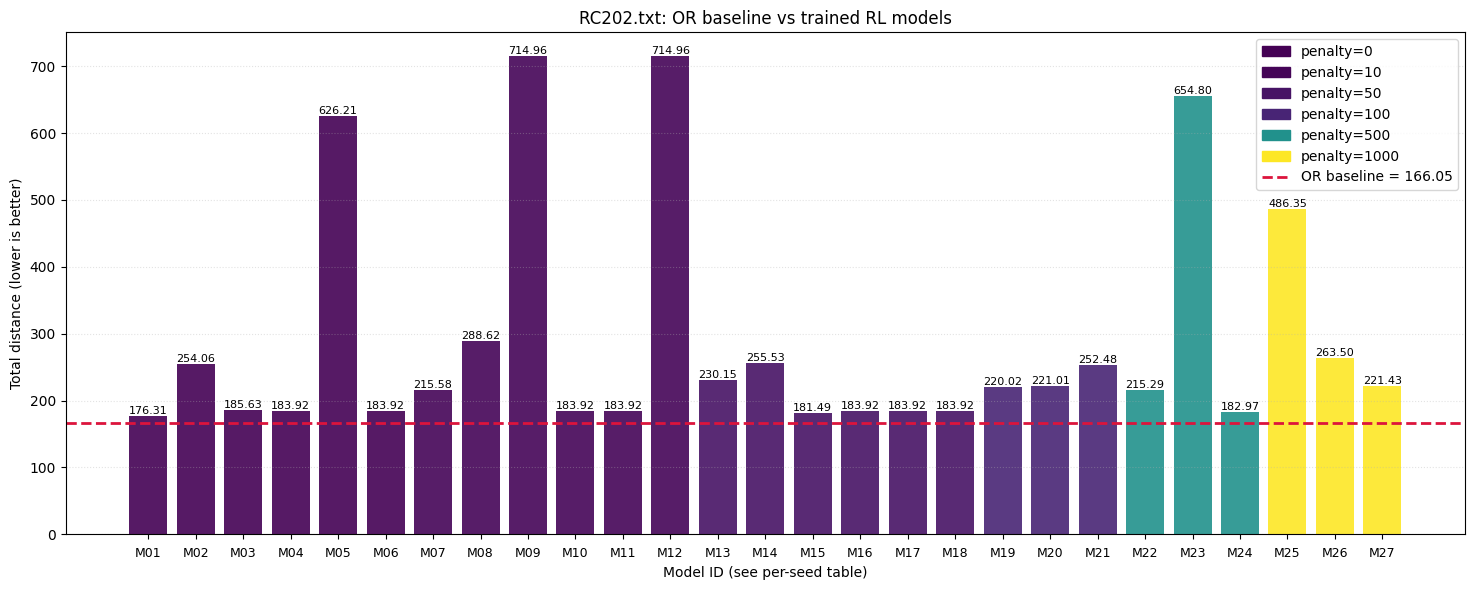


=== RC203.txt | OR baseline: 166.049 ===
Per-seed comparison (model_id matches x-axis):


,model_id,instance_id,family,penalty,learning_rate,seed,rl_distance,gap_vs_or_%
0,M01,RC203.txt,RC1,0.0,0.0001,6238116,183.919,10.76
1,M02,RC203.txt,RC1,0.0,0.0001,7454245,254.063,53.01
2,M03,RC203.txt,RC1,0.0,0.0001,7960100,195.407,17.68
3,M04,RC203.txt,RC1,0.0,0.0005,6238116,182.179,9.71
4,M05,RC203.txt,RC1,0.0,0.0005,7454245,626.213,277.13
5,M06,RC203.txt,RC1,0.0,0.0005,7960100,182.179,9.71
6,M07,RC203.txt,RC1,10.0,0.0001,6238116,215.576,29.83
7,M08,RC203.txt,RC1,10.0,0.0001,7454245,283.953,71.01
8,M09,RC203.txt,RC1,10.0,0.0001,7960100,714.962,330.57
9,M10,RC203.txt,RC1,10.0,0.0005,6238116,182.179,9.71


Aggregated by hyperparameters (across seeds):


,family,penalty,learning_rate,n_seeds,best_distance,mean_distance,std_distance,best_gap_vs_or_%,mean_gap_vs_or_%
0,RC1,0.0,0.0001,3,183.919,211.130,37.623,10.76,27.15
1,RC1,0.0,0.0005,3,182.179,330.190,256.363,9.71,98.85
2,RC1,10.0,0.0001,3,215.576,404.830,270.749,29.83,143.80
3,RC1,10.0,0.0005,3,182.179,359.773,307.602,9.71,116.67
4,RC1,50.0,0.0001,3,181.488,219.792,37.085,9.30,32.37
5,RC1,50.0,0.0005,3,182.179,182.179,0.000,9.71,9.71
6,RC1,100.0,0.0001,3,210.253,227.586,22.107,26.62,37.06
7,RC1,500.0,0.0001,3,177.956,353.888,261.838,7.17,113.12
8,RC1,1000.0,0.0001,3,218.719,322.854,143.347,31.72,94.43


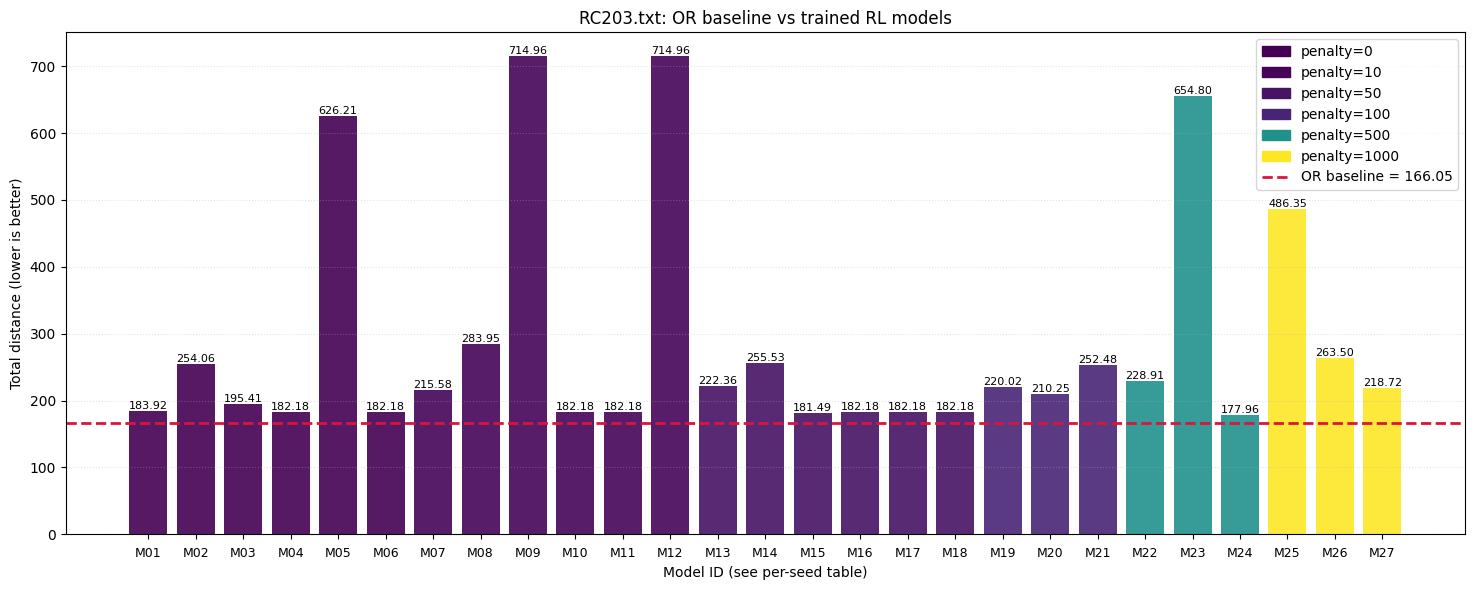


=== RC204.txt | OR baseline: 137.777 ===
Per-seed comparison (model_id matches x-axis):


,model_id,instance_id,family,penalty,learning_rate,seed,rl_distance,gap_vs_or_%
0,M01,RC204.txt,RC1,0.0,0.0001,6238116,189.270,37.37
1,M02,RC204.txt,RC1,0.0,0.0001,7454245,225.447,63.63
2,M03,RC204.txt,RC1,0.0,0.0001,7960100,148.060,7.46
3,M04,RC204.txt,RC1,0.0,0.0005,6238116,187.400,36.02
4,M05,RC204.txt,RC1,0.0,0.0005,7454245,624.435,353.22
5,M06,RC204.txt,RC1,0.0,0.0005,7960100,187.400,36.02
6,M07,RC204.txt,RC1,10.0,0.0001,6238116,150.396,9.16
7,M08,RC204.txt,RC1,10.0,0.0001,7454245,223.268,62.05
8,M09,RC204.txt,RC1,10.0,0.0001,7960100,714.962,418.93
9,M10,RC204.txt,RC1,10.0,0.0005,6238116,187.400,36.02


Aggregated by hyperparameters (across seeds):


,family,penalty,learning_rate,n_seeds,best_distance,mean_distance,std_distance,best_gap_vs_or_%,mean_gap_vs_or_%
0,RC1,0.0,0.0001,3,148.060,187.593,38.721,7.46,36.16
1,RC1,0.0,0.0005,3,187.400,333.079,252.322,36.02,141.75
2,RC1,10.0,0.0001,3,150.396,362.875,307.085,9.16,163.38
3,RC1,10.0,0.0005,3,187.400,363.254,304.588,36.02,163.65
4,RC1,50.0,0.0001,3,175.272,190.480,23.488,27.21,38.25
5,RC1,50.0,0.0005,3,187.400,187.400,0.000,36.02,36.02
6,RC1,100.0,0.0001,3,142.191,172.924,26.959,3.20,25.51
7,RC1,500.0,0.0001,3,182.748,349.490,264.779,32.64,153.66
8,RC1,1000.0,0.0001,3,215.882,282.025,110.706,56.69,104.70


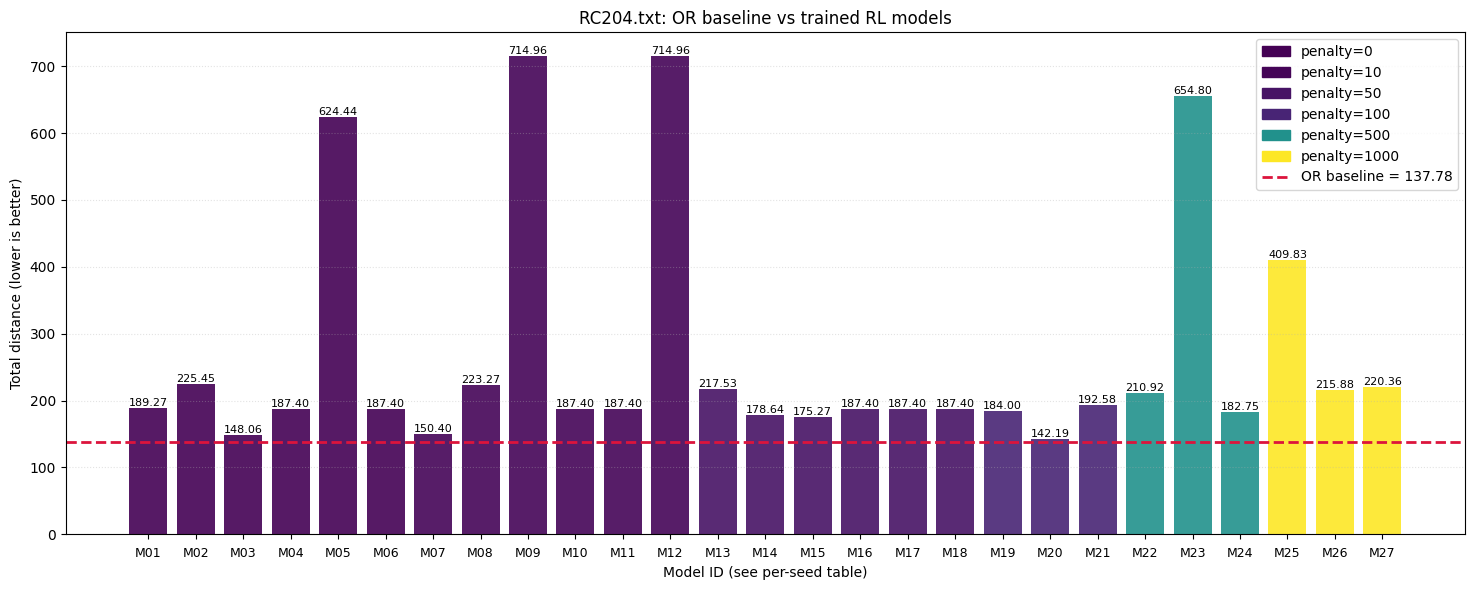


=== RC205.txt | OR baseline: 168.167 ===
Per-seed comparison (model_id matches x-axis):


,model_id,instance_id,family,penalty,learning_rate,seed,rl_distance,gap_vs_or_%
0,M01,RC205.txt,RC1,0.0,0.0001,6238116,201.372,19.74
1,M02,RC205.txt,RC1,0.0,0.0001,7454245,265.439,57.84
2,M03,RC205.txt,RC1,0.0,0.0001,7960100,203.277,20.88
3,M04,RC205.txt,RC1,0.0,0.0005,6238116,204.717,21.73
4,M05,RC205.txt,RC1,0.0,0.0005,7454245,487.625,189.96
5,M06,RC205.txt,RC1,0.0,0.0005,7960100,204.717,21.73
6,M07,RC205.txt,RC1,10.0,0.0001,6238116,219.437,30.49
7,M08,RC205.txt,RC1,10.0,0.0001,7454245,303.554,80.51
8,M09,RC205.txt,RC1,10.0,0.0001,7960100,714.962,325.15
9,M10,RC205.txt,RC1,10.0,0.0005,6238116,204.717,21.73


Aggregated by hyperparameters (across seeds):


,family,penalty,learning_rate,n_seeds,best_distance,mean_distance,std_distance,best_gap_vs_or_%,mean_gap_vs_or_%
0,RC1,0.0,0.0001,3,201.372,223.363,36.451,19.74,32.82
1,RC1,0.0,0.0005,3,204.717,299.020,163.337,21.73,77.81
2,RC1,10.0,0.0001,3,219.437,412.651,265.166,30.49,145.38
3,RC1,10.0,0.0005,3,204.717,374.799,294.590,21.73,122.87
4,RC1,50.0,0.0001,3,214.639,252.537,40.980,27.63,50.17
5,RC1,50.0,0.0005,3,204.717,204.717,0.000,21.73,21.73
6,RC1,100.0,0.0001,3,184.206,214.942,26.621,9.54,27.81
7,RC1,500.0,0.0001,3,182.499,362.622,255.311,8.52,115.63
8,RC1,1000.0,0.0001,3,219.437,390.356,232.260,30.49,132.12


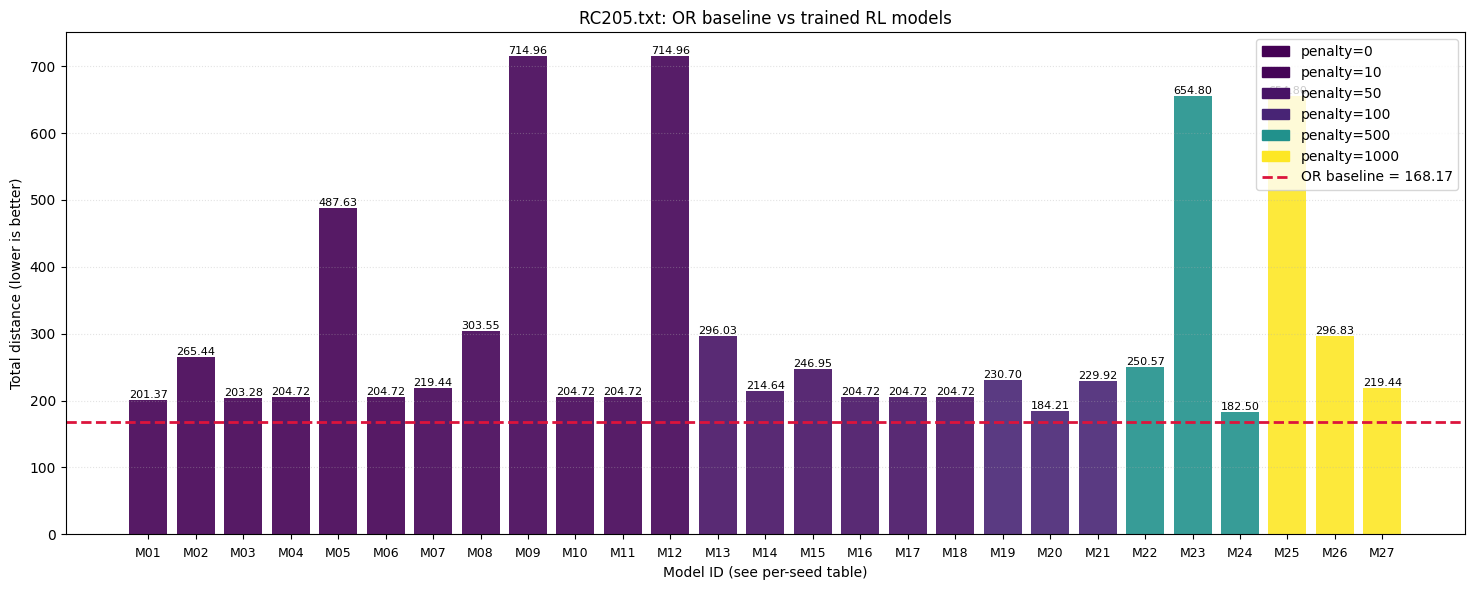


=== RC206.txt | OR baseline: 178.088 ===
Per-seed comparison (model_id matches x-axis):


,model_id,instance_id,family,penalty,learning_rate,seed,rl_distance,gap_vs_or_%
0,M01,RC206.txt,RC1,0.0,0.0001,6238116,231.332,29.90
1,M02,RC206.txt,RC1,0.0,0.0001,7454245,224.950,26.31
2,M03,RC206.txt,RC1,0.0,0.0001,7960100,190.433,6.93
3,M04,RC206.txt,RC1,0.0,0.0005,6238116,248.476,39.52
4,M05,RC206.txt,RC1,0.0,0.0005,7454245,499.030,180.22
5,M06,RC206.txt,RC1,0.0,0.0005,7960100,248.476,39.52
6,M07,RC206.txt,RC1,10.0,0.0001,6238116,224.301,25.95
7,M08,RC206.txt,RC1,10.0,0.0001,7454245,216.412,21.52
8,M09,RC206.txt,RC1,10.0,0.0001,7960100,654.043,267.26
9,M10,RC206.txt,RC1,10.0,0.0005,6238116,248.476,39.52


Aggregated by hyperparameters (across seeds):


,family,penalty,learning_rate,n_seeds,best_distance,mean_distance,std_distance,best_gap_vs_or_%,mean_gap_vs_or_%
0,RC1,0.0,0.0001,3,190.433,215.571,22.003,6.93,21.05
1,RC1,0.0,0.0005,3,248.476,331.994,144.657,39.52,86.42
2,RC1,10.0,0.0001,3,216.412,364.918,250.420,21.52,104.91
3,RC1,10.0,0.0005,3,248.476,403.971,269.326,39.52,126.84
4,RC1,50.0,0.0001,3,218.497,282.397,64.186,22.69,58.57
5,RC1,50.0,0.0005,3,248.476,248.476,0.000,39.52,39.52
6,RC1,100.0,0.0001,3,222.249,251.003,38.265,24.80,40.94
7,RC1,500.0,0.0001,3,263.514,402.654,218.754,47.97,126.10
8,RC1,1000.0,0.0001,3,219.521,387.152,234.241,23.27,117.39


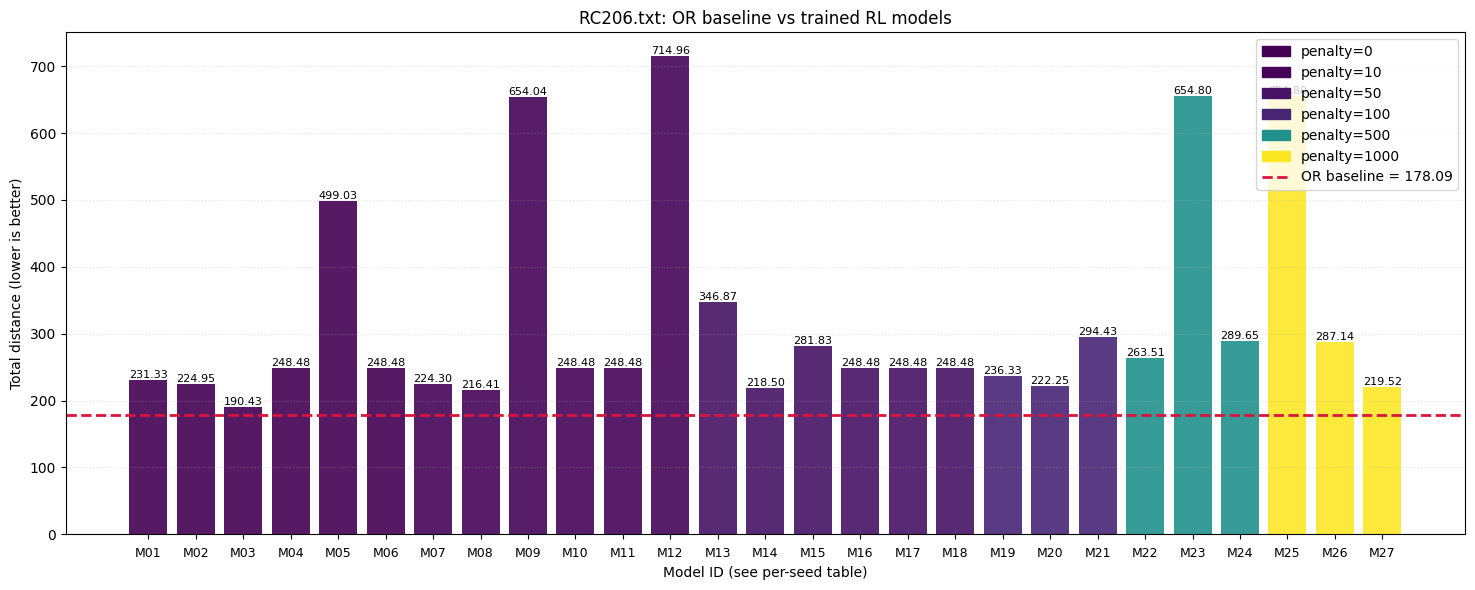


=== RC207.txt | OR baseline: 168.167 ===
Per-seed comparison (model_id matches x-axis):


,model_id,instance_id,family,penalty,learning_rate,seed,rl_distance,gap_vs_or_%
0,M01,RC207.txt,RC1,0.0,0.0001,6238116,201.718,19.95
1,M02,RC207.txt,RC1,0.0,0.0001,7454245,259.194,54.13
2,M03,RC207.txt,RC1,0.0,0.0001,7960100,218.940,30.19
3,M04,RC207.txt,RC1,0.0,0.0005,6238116,230.952,37.33
4,M05,RC207.txt,RC1,0.0,0.0005,7454245,492.566,192.90
5,M06,RC207.txt,RC1,0.0,0.0005,7960100,230.952,37.33
6,M07,RC207.txt,RC1,10.0,0.0001,6238116,226.952,34.96
7,M08,RC207.txt,RC1,10.0,0.0001,7454245,281.693,67.51
8,M09,RC207.txt,RC1,10.0,0.0001,7960100,714.962,325.15
9,M10,RC207.txt,RC1,10.0,0.0005,6238116,230.952,37.33


Aggregated by hyperparameters (across seeds):


,family,penalty,learning_rate,n_seeds,best_distance,mean_distance,std_distance,best_gap_vs_or_%,mean_gap_vs_or_%
0,RC1,0.0,0.0001,3,201.718,226.617,29.497,19.95,34.76
1,RC1,0.0,0.0005,3,230.952,318.157,151.042,37.33,89.19
2,RC1,10.0,0.0001,3,226.952,407.869,267.355,34.96,142.54
3,RC1,10.0,0.0005,3,230.952,392.289,279.443,37.33,133.27
4,RC1,50.0,0.0001,3,223.807,287.551,70.067,33.09,70.99
5,RC1,50.0,0.0005,3,230.952,230.952,0.000,37.33,37.33
6,RC1,100.0,0.0001,3,193.399,214.808,20.464,15.00,27.73
7,RC1,500.0,0.0001,3,181.956,354.369,261.125,8.20,110.72
8,RC1,1000.0,0.0001,3,217.694,374.576,243.258,29.45,122.74


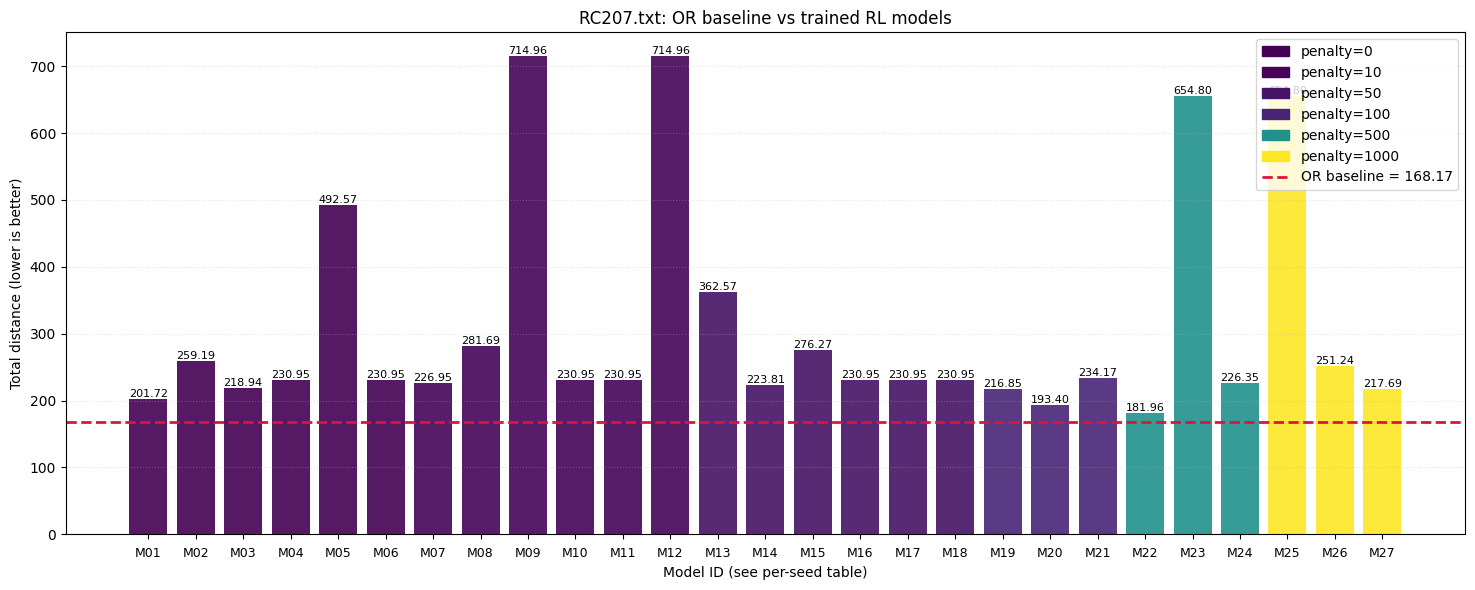


=== RC208.txt | OR baseline: 138.060 ===
Per-seed comparison (model_id matches x-axis):


,model_id,instance_id,family,penalty,learning_rate,seed,rl_distance,gap_vs_or_%
0,M01,RC208.txt,RC1,0.0,0.0001,6238116,149.091,7.99
1,M02,RC208.txt,RC1,0.0,0.0001,7454245,146.699,6.26
2,M03,RC208.txt,RC1,0.0,0.0001,7960100,152.279,10.30
3,M04,RC208.txt,RC1,0.0,0.0005,6238116,163.677,18.55
4,M05,RC208.txt,RC1,0.0,0.0005,7454245,623.175,351.38
5,M06,RC208.txt,RC1,0.0,0.0005,7960100,163.677,18.55
6,M07,RC208.txt,RC1,10.0,0.0001,6238116,145.925,5.70
7,M08,RC208.txt,RC1,10.0,0.0001,7454245,211.497,53.19
8,M09,RC208.txt,RC1,10.0,0.0001,7960100,714.962,417.86
9,M10,RC208.txt,RC1,10.0,0.0005,6238116,163.677,18.55


Aggregated by hyperparameters (across seeds):


,family,penalty,learning_rate,n_seeds,best_distance,mean_distance,std_distance,best_gap_vs_or_%,mean_gap_vs_or_%
0,RC1,0.0,0.0001,3,146.699,149.356,2.799,6.26,8.18
1,RC1,0.0,0.0005,3,163.677,316.843,265.291,18.55,129.50
2,RC1,10.0,0.0001,3,145.925,357.461,311.336,5.70,158.92
3,RC1,10.0,0.0005,3,163.677,347.439,318.284,18.55,151.66
4,RC1,50.0,0.0001,3,158.301,216.199,51.449,14.66,56.60
5,RC1,50.0,0.0005,3,163.677,163.677,0.000,18.55,18.55
6,RC1,100.0,0.0001,3,144.466,148.509,3.507,4.64,7.57
7,RC1,500.0,0.0001,3,147.589,428.045,257.834,6.90,210.04
8,RC1,1000.0,0.0001,3,157.214,337.349,275.751,13.87,144.35


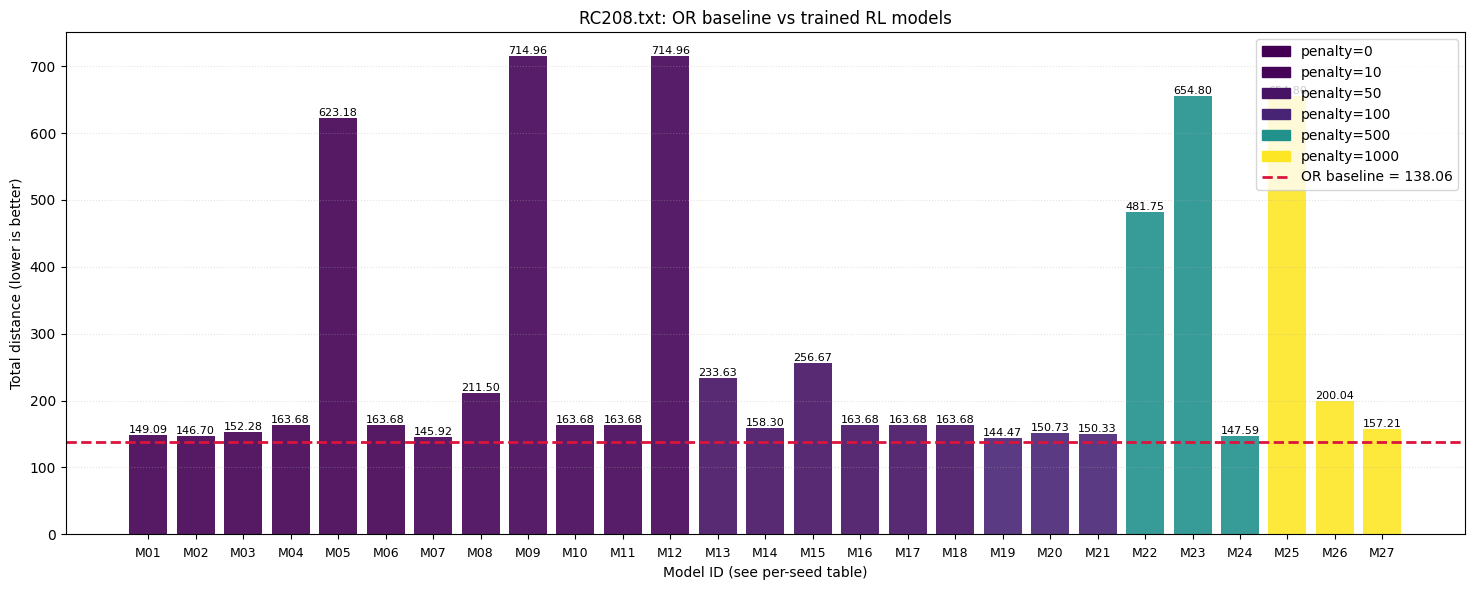

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from IPython.display import display

# Build a tidy table from rl_solutions
rows = []
for key, sol in rl_solutions.items():
    instance_id, file_name = key.split("_", 1)
    params = parse_file_name(file_name)
    rows.append({
        "instance_id": instance_id,
        "model_file": file_name,
        "rl_distance": sol.total_distance,
        "family": params["family"],
        "num_customers": params["num_customers"],
        "penalty": params["penalty"],
        "learning_rate": params["learning_rate"],
        "seed": params["seed"],
    })

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError("rl_solutions is empty. Run the inference cell first.")

instance_ids = sorted(df["instance_id"].unique())
n_instances = len(instance_ids)
print(f"Building {n_instances} plots and tables (one per instance)...")

global_penalties = sorted(df["penalty"].unique())
pen_norm = Normalize(vmin=min(global_penalties), vmax=max(global_penalties)) if len(global_penalties) > 1 else None
cmap = plt.colormaps["viridis"]

for instance_id in instance_ids:
    sub = df[df["instance_id"] == instance_id].copy()
    sub = sub.sort_values(["penalty", "learning_rate", "seed"]).reset_index(drop=True)

    or_baseline = or_solutions[instance_id].total_distance
    sub["gap_vs_or_%"] = (sub["rl_distance"] / or_baseline - 1.0) * 100.0

    # Short model IDs for readable x-axis
    sub["model_id"] = [f"M{i:02d}" for i in range(1, len(sub) + 1)]

    # ---- Table 1: direct comparison by hyperparameters and seed ----
    per_seed_table = sub[[
        "model_id", "instance_id", "family", "penalty", "learning_rate", "seed", "rl_distance", "gap_vs_or_%"
    ]].copy()
    per_seed_table["rl_distance"] = per_seed_table["rl_distance"].round(3)
    per_seed_table["gap_vs_or_%"] = per_seed_table["gap_vs_or_%"].round(2)

    print(f"\n=== {instance_id} | OR baseline: {or_baseline:.3f} ===")
    print("Per-seed comparison (model_id matches x-axis):")
    display(per_seed_table.reset_index(drop=True))

    # ---- Table 2: same model settings aggregated across seeds ----
    agg_table = (
        sub.groupby(["family", "penalty", "learning_rate"], as_index=False)
        .agg(
            n_seeds=("seed", "nunique"),
            best_distance=("rl_distance", "min"),
            mean_distance=("rl_distance", "mean"),
            std_distance=("rl_distance", "std"),
        )
    )
    agg_table["best_gap_vs_or_%"] = (agg_table["best_distance"] / or_baseline - 1.0) * 100.0
    agg_table["mean_gap_vs_or_%"] = (agg_table["mean_distance"] / or_baseline - 1.0) * 100.0
    agg_table["best_distance"] = agg_table["best_distance"].round(3)
    agg_table["mean_distance"] = agg_table["mean_distance"].round(3)
    agg_table["std_distance"] = agg_table["std_distance"].fillna(0.0).round(3)
    agg_table["best_gap_vs_or_%"] = agg_table["best_gap_vs_or_%"].round(2)
    agg_table["mean_gap_vs_or_%"] = agg_table["mean_gap_vs_or_%"].round(2)
    agg_table = agg_table.sort_values(["penalty", "learning_rate"])

    print("Aggregated by hyperparameters (across seeds):")
    display(agg_table.reset_index(drop=True))

    # ---- Plot ----
    if pen_norm is None:
        colors = [cmap(0.6)] * len(sub)
    else:
        colors = [cmap(pen_norm(p)) for p in sub["penalty"]]

    fig_width = max(12, 0.55 * len(sub))
    fig, ax = plt.subplots(figsize=(fig_width, 6))
    x = list(range(len(sub)))
    bars = ax.bar(x, sub["rl_distance"], color=colors, alpha=0.9)

    ax.axhline(or_baseline, color="crimson", linestyle="--", linewidth=2)

    for b, value in zip(bars, sub["rl_distance"]):
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height(),
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.set_title(f"{instance_id}: OR baseline vs trained RL models")
    ax.set_ylabel("Total distance (lower is better)")
    ax.set_xlabel("Model ID (see per-seed table)")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["model_id"], fontsize=9)
    ax.tick_params(axis="x", rotation=0, pad=6)
    ax.grid(axis="y", linestyle=":", alpha=0.35)

    penalty_handles = []
    for p in sorted(sub["penalty"].unique()):
        color = cmap(pen_norm(p)) if pen_norm is not None else cmap(0.6)
        penalty_handles.append(mpatches.Patch(color=color, label=f"penalty={p:g}"))

    or_handle = plt.Line2D([0], [0], color="crimson", linestyle="--", linewidth=2, label=f"OR baseline = {or_baseline:.2f}")
    ax.legend(handles=[*penalty_handles, or_handle], loc="upper right")

    fig.tight_layout()
    plt.show()

Seed sensitivity per fixed setting (instance + hyperparams):


,instance_id,family,penalty,learning_rate,n_seeds,min_distance,max_distance,spread,std_distance,cv_%
0,RC208.txt,RC1,10.0,0.0001,3,145.924957,714.961731,569.036774,311.335693,87.096372
1,RC204.txt,RC1,10.0,0.0001,3,150.395523,714.961731,564.566208,307.085341,84.625663
2,RC208.txt,RC1,10.0,0.0005,3,163.677170,714.961731,551.284561,318.284290,91.608764
3,RC203.txt,RC1,10.0,0.0005,3,182.179031,714.961731,532.782700,307.602235,85.498914
4,RC202.txt,RC1,10.0,0.0005,3,183.918060,714.961731,531.043671,306.598206,84.946107
...,...,...,...,...,...,...,...,...,...,...
67,RC204.txt,RC1,50.0,0.0005,3,187.400177,187.400177,0.000000,0.000000,0.000000
68,RC205.txt,RC1,50.0,0.0005,3,204.717026,204.717026,0.000000,0.000000,0.000000
69,RC206.txt,RC1,50.0,0.0005,3,248.475830,248.475830,0.000000,0.000000,0.000000
70,RC207.txt,RC1,50.0,0.0005,3,230.952393,230.952393,0.000000,0.000000,0.000000


Top 10 most seed-sensitive settings by spread:


,instance_id,family,penalty,learning_rate,spread,std_distance,cv_%
0,RC208.txt,RC1,10.0,0.0001,569.036774,311.335693,87.096372
1,RC204.txt,RC1,10.0,0.0001,564.566208,307.085341,84.625663
2,RC208.txt,RC1,10.0,0.0005,551.284561,318.284290,91.608764
3,RC203.txt,RC1,10.0,0.0005,532.782700,307.602235,85.498914
4,RC202.txt,RC1,10.0,0.0005,531.043671,306.598206,84.946107
5,RC204.txt,RC1,10.0,0.0005,527.561554,304.587805,83.849808
6,RC205.txt,RC1,10.0,0.0005,510.244705,294.589918,78.599526
7,RC208.txt,RC1,500.0,0.0001,507.208771,257.833749,60.235142
8,RC203.txt,RC1,10.0,0.0001,499.385712,270.748921,66.879605
9,RC202.txt,RC1,10.0,0.0001,499.385712,269.719674,66.370594


Matched settings with all seeds present: 72
Per-seed summary across matched settings:


,seed,mean_distance,std_distance,mean_regret,std_regret
0,6238116,264.431823,132.175052,63.647869,125.264186
1,7454245,311.464307,168.424124,110.680353,167.124744
2,7960100,322.807696,210.143097,122.023742,207.028988


How often each seed attains the best distance (ties included):


,seed,num_best,best_rate_%
0,6238116,40,55.555556
1,7960100,35,48.611111
2,7454245,29,40.277778


Friedman test across seeds -> statistic=2.1333, p-value=0.344154
Interpretation: no significant seed effect detected at 5% level.


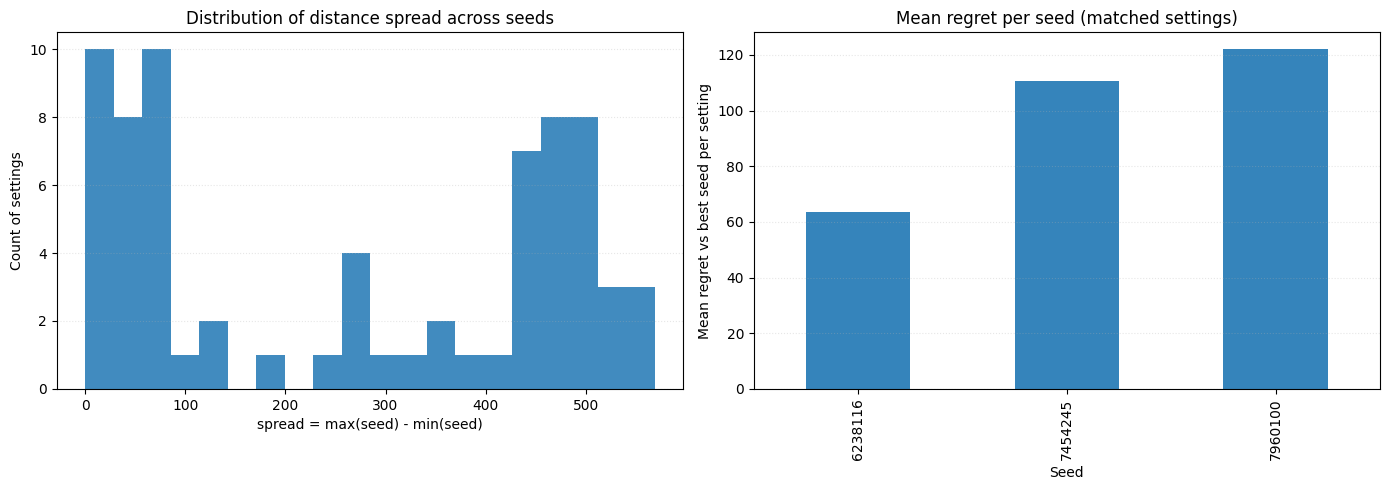

Average spread across settings: 266.734
Median spread across settings: 275.267


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    from scipy.stats import friedmanchisquare
    _has_scipy = True
except Exception:
    _has_scipy = False

# ------------------------------------------------------------------
# Seed dependence analysis
# Uses df from Cell 5: columns include instance_id, penalty, learning_rate, seed, rl_distance
# ------------------------------------------------------------------
if "df" not in globals() or df.empty:
    raise ValueError("df is not available. Run Cell 5 first.")

seed_df = df.copy()
seed_df = seed_df.sort_values(["instance_id", "penalty", "learning_rate", "seed"]).reset_index(drop=True)
seed_df["setting_id"] = (
    seed_df["instance_id"].astype(str)
    + "|p=" + seed_df["penalty"].astype(str)
    + "|lr=" + seed_df["learning_rate"].astype(str)
    + "|fam=" + seed_df["family"].astype(str)
)

# Distance spread across seeds for each fixed model setting + instance
per_setting_spread = (
    seed_df.groupby(["instance_id", "family", "penalty", "learning_rate", "setting_id"], as_index=False)
    .agg(
        n_seeds=("seed", "nunique"),
        min_distance=("rl_distance", "min"),
        max_distance=("rl_distance", "max"),
        mean_distance=("rl_distance", "mean"),
        std_distance=("rl_distance", "std"),
    )
)
per_setting_spread["std_distance"] = per_setting_spread["std_distance"].fillna(0.0)
per_setting_spread["spread"] = per_setting_spread["max_distance"] - per_setting_spread["min_distance"]
per_setting_spread["cv_%"] = np.where(
    per_setting_spread["mean_distance"] != 0,
    100.0 * per_setting_spread["std_distance"] / per_setting_spread["mean_distance"],
    np.nan,
)

print("Seed sensitivity per fixed setting (instance + hyperparams):")
display(
    per_setting_spread[[
        "instance_id", "family", "penalty", "learning_rate", "n_seeds", "min_distance", "max_distance", "spread", "std_distance", "cv_%"
    ]]
    .sort_values(["spread", "std_distance"], ascending=False)
    .reset_index(drop=True)
)

# Top unstable settings (largest spread)
top_unstable = per_setting_spread.sort_values("spread", ascending=False).head(10)
print("Top 10 most seed-sensitive settings by spread:")
display(
    top_unstable[[
        "instance_id", "family", "penalty", "learning_rate", "spread", "std_distance", "cv_%"
    ]].reset_index(drop=True)
)

# Build matched matrix (rows = identical settings, cols = seeds)
pivot = seed_df.pivot_table(
    index="setting_id",
    columns="seed",
    values="rl_distance",
    aggfunc="mean",
)

# keep only settings where all seeds are present
pivot_complete = pivot.dropna(axis=0, how="any")
print(f"Matched settings with all seeds present: {len(pivot_complete)}")

if len(pivot_complete) == 0:
    print("Not enough complete settings across seeds to test dependence.")
else:
    # Convert distances to regret per setting to compare fairly across instances/settings
    regrets = pivot_complete.sub(pivot_complete.min(axis=1), axis=0)

    # Aggregate by seed
    seed_summary = pd.DataFrame({
        "mean_distance": pivot_complete.mean(axis=0),
        "std_distance": pivot_complete.std(axis=0),
        "mean_regret": regrets.mean(axis=0),
        "std_regret": regrets.std(axis=0),
    }).sort_index()
    seed_summary.index.name = "seed"
    seed_summary = seed_summary.reset_index()

    print("Per-seed summary across matched settings:")
    display(seed_summary)

    # Win count: how often each seed is the best (including ties)
    is_best = pivot_complete.eq(pivot_complete.min(axis=1), axis=0)
    win_counts = is_best.sum(axis=0).rename("num_best").reset_index()
    win_counts.columns = ["seed", "num_best"]
    win_counts["best_rate_%"] = 100.0 * win_counts["num_best"] / len(pivot_complete)
    win_counts = win_counts.sort_values("num_best", ascending=False)

    print("How often each seed attains the best distance (ties included):")
    display(win_counts.reset_index(drop=True))

    # Statistical test: Friedman test on matched settings
    if _has_scipy and pivot_complete.shape[1] >= 2 and pivot_complete.shape[0] >= 2:
        seed_cols = list(pivot_complete.columns)
        stat, pvalue = friedmanchisquare(*[pivot_complete[c].values for c in seed_cols])
        print(f"Friedman test across seeds -> statistic={stat:.4f}, p-value={pvalue:.6g}")
        if pvalue < 0.05:
            print("Interpretation: reject equal-seed-performance hypothesis (seed-dependent behavior likely).")
        else:
            print("Interpretation: no significant seed effect detected at 5% level.")
    else:
        print("Friedman test skipped (scipy unavailable or insufficient matched data).")

    # ---------------- Visual diagnostics ----------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: spread distribution by setting
    axes[0].hist(per_setting_spread["spread"], bins=20, alpha=0.85)
    axes[0].set_title("Distribution of distance spread across seeds")
    axes[0].set_xlabel("spread = max(seed) - min(seed)")
    axes[0].set_ylabel("Count of settings")
    axes[0].grid(axis="y", linestyle=":", alpha=0.3)

    # Right: mean regret per seed (lower is better)
    regrets.mean(axis=0).sort_index().plot(kind="bar", ax=axes[1], alpha=0.9)
    axes[1].set_title("Mean regret per seed (matched settings)")
    axes[1].set_xlabel("Seed")
    axes[1].set_ylabel("Mean regret vs best seed per setting")
    axes[1].grid(axis="y", linestyle=":", alpha=0.3)

    fig.tight_layout()
    plt.show()

    # Optional compact indicator for quick read
    mean_spread = per_setting_spread["spread"].mean()
    median_spread = per_setting_spread["spread"].median()
    print(f"Average spread across settings: {mean_spread:.3f}")
    print(f"Median spread across settings: {median_spread:.3f}")